<a href="https://colab.research.google.com/github/SulabhSamir94/Weekend_Data_Challenge_CodingWithSubin/blob/main/DatasetCleaing_and_ColumnEngineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Weekend Data Challenge #06:Car Price Prediction

**Objective:** Clean a kaggle dataset, and use it to predict the price and milage of cars

## Setup and loading
Importing required libraries and raw dataset.


In [1]:
# Importing required libraries for this challenge
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importing our, required Kaggle Dataset through data explorer
import kagglehub
path = kagglehub.dataset_download("taeefnajib/used-car-price-prediction-dataset")

100%|██████████| 109k/109k [00:00<00:00, 80.7MB/s]

Extracting files...


In [3]:
# Defining our Dataset
df = pd.read_csv(path + "/used_cars.csv")
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB
None


**What are the things that we could search for, or look at based on the information above?**
1. We need to look for the values in the columns - `'fuel_type'`, `'accident'` and `'clean_title'`. We also need to make a judgement whether it these columns are useful for our analysis or if we should leave the as such.
2. Some columns like `'price'` and `'milage'` seem like they could be numerical instead of object-type.

*These would be our judgement for now.*

### Looking into `'price'` and `'milage'`

In [4]:
# We can inspect what the object-type data in 'price' and 'milage' look like
print("The initial data in 'price' and 'milage' columns:")
print(df[['price', 'milage']].head())

The initial data in 'price' and 'milage' columns:
     price      milage
0  $10,300  51,000 mi.
1  $38,005  34,742 mi.
2  $54,598  22,372 mi.
3  $15,500  88,900 mi.
4  $34,999   9,835 mi.


In [5]:
# We need to get rid of the characters '$' and 'mi.'
df['price'] = df['price'].str.replace('$', '', regex = False).str.replace(',', '', regex = False).astype(float)
df['milage'] = df['milage'].str.replace('mi.', '', regex = False).str.replace(',', '', regex = False).astype(float)
print("The new data in 'price' and 'milage' columns:")
print(df[['price', 'milage']].head())

The new data in 'price' and 'milage' columns:
     price   milage
0  10300.0  51000.0
1  38005.0  34742.0
2  54598.0  22372.0
3  15500.0  88900.0
4  34999.0   9835.0


### Handling the missing values with judgement in columns `'fuel_type'`, `'accident'`, and `'clean_title'`

In [6]:
# Lets look at the unique values in each of the columns
print('Unique values in "fuel_type" column:')
for ft in df['fuel_type'].unique():
  print(f"- {ft}")
print('\nUnique values in "accident" column:')
for ac in df['accident'].unique():
  print(f"- {ac}")
print('\nUnique values in "clean_title" column:')
for ct in df['clean_title'].unique():
  print(f"- {ct}")

Unique values in "fuel_type" column:
- E85 Flex Fuel
- Gasoline
- Hybrid
- nan
- Diesel
- Plug-In Hybrid
- –
- not supported

Unique values in "accident" column:
- At least 1 accident or damage reported
- None reported
- nan

Unique values in "clean_title" column:
- Yes
- nan


In [7]:
# We see nan in almost all the columns.
# We can take the following approach:

df['fuel_type'] = df['fuel_type'].fillna('Unknown')
# It refers to the fact that we don't know the fuel type for these cars.

df['accident'] = df['accident'].fillna('Unknown')
# It refers to the fact that we don't have idea about it, which collides with none-reported.
# So, lets consider that ever if its reported, we don't have it recorded here.
# Sounds irresposible, but lets go with that for now.

df['clean_title'] = df['clean_title'].fillna('No')
# It's the complementary of 'Yes'

### Engineerig a `'car_age'` and `'milage_per_year'` columns

In [8]:
# Defining 'car_age'
df['car_age'] = 2026 - df['model_year'] #'model_year' being int type
print(df['car_age'].head())
# Looking for values '0' in 'car_age'.
print("Number of cars with 'car_age' = 0:")
print(df[df['car_age'] == 0].shape[0])

0    13
1     5
2     4
3    11
4     5
Name: car_age, dtype: int64
Number of cars with 'car_age' = 0:
0


In [9]:
# We can make the column 'milag_per_year' without the case of division by 0
df['milage_per_year'] = df['milage'] / df['car_age']
print(df['milage_per_year'].head())


0    3923.076923
1    6948.400000
2    5593.000000
3    8081.818182
4    1967.000000
Name: milage_per_year, dtype: float64


### Creating `'brand_teir'` column
*This is to compare price based on brands.*

In [10]:
# Lets see what brands of car we have here.
print('Unique brands in the dataset:')
for brand in df['brand'].unique():
  print(f"- {brand}")
print(f"Number of brands: {df['brand'].nunique()}")

Unique brands in the dataset:
- Ford
- Hyundai
- Lexus
- INFINITI
- Audi
- Acura
- BMW
- Tesla
- Land
- Aston
- Toyota
- Lincoln
- Jaguar
- Mercedes-Benz
- Dodge
- Nissan
- Genesis
- Chevrolet
- Kia
- Jeep
- Bentley
- Honda
- Lucid
- MINI
- Porsche
- Hummer
- Chrysler
- Volvo
- Cadillac
- Lamborghini
- Maserati
- Volkswagen
- Subaru
- Rivian
- GMC
- RAM
- Alfa
- Ferrari
- Scion
- Mitsubishi
- Mazda
- Saturn
- Bugatti
- Polestar
- Rolls-Royce
- McLaren
- Buick
- Lotus
- Pontiac
- FIAT
- Karma
- Saab
- Mercury
- Plymouth
- smart
- Maybach
- Suzuki
Number of brands: 57


In [11]:
# There are 57 car brands.
# I have no idea which of them are luxury brands.
# First lets complete a task from the Challenge:
# Correct the name of Land Rover
land_rover_mask = df['brand'] == "Land" # Indicating that there's only "Land" as the name fo the brand
df.loc[land_rover_mask, 'brand'] = "Land Rover" # Correcting the name
# At the same time, the corresponding 'model' columns have 'Rover' written in it.
df.loc[land_rover_mask, 'model'] = df.loc[land_rover_mask, 'model'].str.replace('Rover', '', n = 1, regex = False)
# This should replace the 'Rover' with empty space.
print("Unique brands in the dataset:")# Checking if it worked
for brand in df['brand'].unique():
  print(f"- {brand}")

Unique brands in the dataset:
- Ford
- Hyundai
- Lexus
- INFINITI
- Audi
- Acura
- BMW
- Tesla
- Land Rover
- Aston
- Toyota
- Lincoln
- Jaguar
- Mercedes-Benz
- Dodge
- Nissan
- Genesis
- Chevrolet
- Kia
- Jeep
- Bentley
- Honda
- Lucid
- MINI
- Porsche
- Hummer
- Chrysler
- Volvo
- Cadillac
- Lamborghini
- Maserati
- Volkswagen
- Subaru
- Rivian
- GMC
- RAM
- Alfa
- Ferrari
- Scion
- Mitsubishi
- Mazda
- Saturn
- Bugatti
- Polestar
- Rolls-Royce
- McLaren
- Buick
- Lotus
- Pontiac
- FIAT
- Karma
- Saab
- Mercury
- Plymouth
- smart
- Maybach
- Suzuki


The above problem has been solved.

For luxury brands, we can take the names from the list and ask AI to help us.

In [12]:
# Here's the result
luxury_brands = [
    "Acura",
    "Alfa",
    "Aston",
    "Audi",
    "Bentley",
    "BMW",
    "Bugatti",
    "Cadillac",
    "Ferrari",
    "Genesis",
    "INFINITI",
    "Jaguar",
    "Karma",
    "Lamborghini",
    "Land Rover",
    "Lexus",
    "Lincoln",
    "Lotus",
    "Lucid",
    "Maserati",
    "Maybach",
    "McLaren",
    "Mercedes-Benz",
    "Polestar",
    "Porsche",
    "Rolls-Royce",
    "Volvo",
]

# Defining 'brand_teir'
df['brand_teir'] = df['brand'].apply(lambda x: 'Luxury' if x in luxury_brands else 'Non-Luxury')

car_brand_teir = df[['brand', 'brand_teir']]# Checking it
print(car_brand_teir.head())

      brand  brand_teir
0      Ford  Non-Luxury
1   Hyundai  Non-Luxury
2     Lexus      Luxury
3  INFINITI      Luxury
4      Audi      Luxury


### Visualizing it

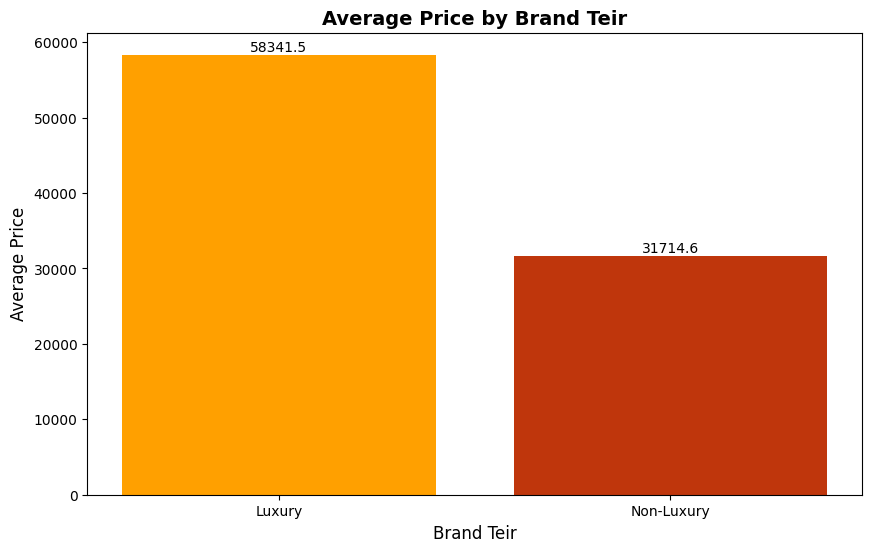

In [13]:
from numpy import average
# The first visualization is that of average price by brand_teir
# We use bar-chart for it.
average_price_by_brand_teir = df.groupby('brand_teir')['price'].mean()
plt.figure(figsize = (10, 6))
plt.bar(average_price_by_brand_teir.index, average_price_by_brand_teir.values, color= ['#FFA000', '#bf360c'])
plt.xlabel('Brand Teir', size = 12)
plt.ylabel('Average Price', size = 12)
plt.title('Average Price by Brand Teir', size = 14, fontweight = 'bold')
plt.bar_label(plt.gca().containers[0])
plt.show()


Text(0.5, 1.0, 'Price by Car Age')

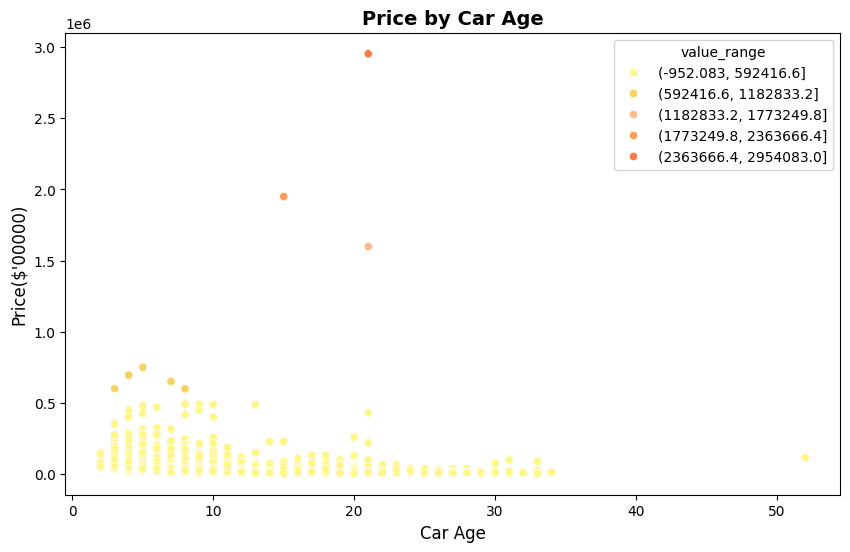

In [19]:
# Scatter plot for 'car_age' vs 'price'
plt.figure(figsize = (10, 6))
df['value_range'] = pd.cut(df['price'], bins = 5)
sns.scatterplot(data = df, x = 'car_age', y = 'price', hue = 'value_range',
                palette = ['#fff689', '#f4d35e','#ffb88a','#ff9c5b','#f67b45'])
plt.xlabel('Car Age', size = 12)
plt.ylabel('Price($\'00000)', size = 12)
plt.title('Price by Car Age', size = 14, fontweight = 'bold')

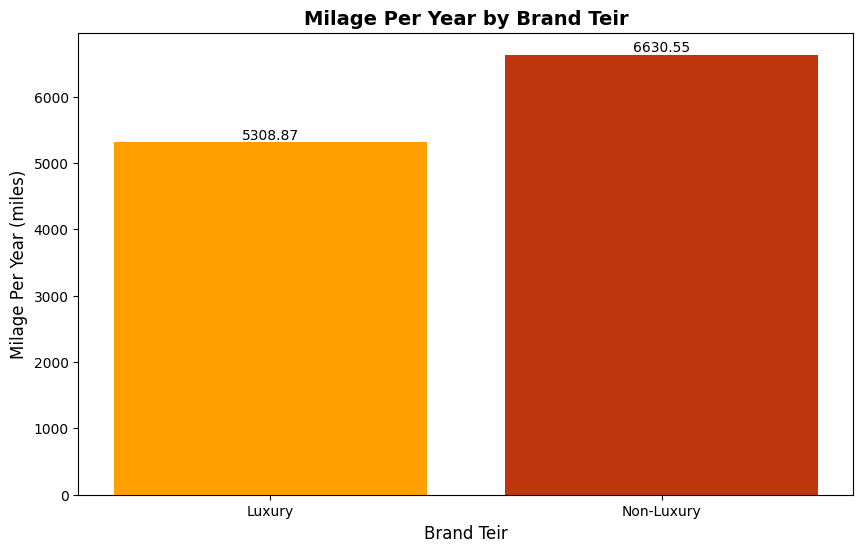

In [20]:
# Visualization for 'milage_per_year' by 'brand_teir'
# Using bar-graphs for it
plt.figure(figsize = (10, 6))
milage_per_year_by_brand_teir = df.groupby('brand_teir')['milage_per_year'].mean()
plt.bar(milage_per_year_by_brand_teir.index, milage_per_year_by_brand_teir.values,
         color = ['#FFA000', '#bf360c'])
plt.xlabel('Brand Teir', size = 12)
plt.ylabel('Milage Per Year (miles)', size = 12)
plt.title('Milage Per Year by Brand Teir', size = 14, fontweight = 'bold')
plt.bar_label(plt.gca().containers[0])
plt.show()

### Bonus Question: Finding unusual `'milage_per_year'`

In [26]:
# Lets look at the smallest and largest values of 'milage_per_year'
mil_p_age = df['milage_per_year'].sort_values(ascending = True)
print("The smallest values of 'milage_per_year':")
print(mil_p_age.head(10))
print("\nThe highest values of 'milage_per_year':")
print(mil_p_age.tail(10))

The smallest values of 'milage_per_year':
3018    25.000000
1848    26.250000
487     28.750000
3860    45.454545
3600    51.333333
2407    53.000000
331     61.538462
1691    62.000000
3764    62.500000
501     65.000000
Name: milage_per_year, dtype: float64

The highest values of 'milage_per_year':
2123    20875.000000
1281    21300.000000
665     21706.777778
2529    22833.333333
999     23063.444444
2926    27111.111111
2232    29375.000000
116     29566.800000
2764    31153.846154
3348    39900.000000
Name: milage_per_year, dtype: float64


In [31]:
# Lets look at the milage of these cars along with model year
print("Highest 'milage_per_year' with their 'milage' is as follows:")
print(df.loc[mil_p_age.tail(10).index, ['milage_per_year', 'milage', 'model_year', 'brand']])
# The 'brand' column was added later
# The data looks fine

Highest 'milage_per_year' with their 'milage' is as follows:
      milage_per_year    milage  model_year          brand
2123     20875.000000  167000.0        2018         Nissan
1281     21300.000000   85200.0        2022      Chevrolet
665      21706.777778  195361.0        2017      Chevrolet
2529     22833.333333  137000.0        2020      Chevrolet
999      23063.444444  207571.0        2017      Chevrolet
2926     27111.111111  244000.0        2017           Ford
2232     29375.000000  235000.0        2018           Ford
116      29566.800000  147834.0        2021            RAM
2764     31153.846154  405000.0        2013          Honda
3348     39900.000000  399000.0        2016  Mercedes-Benz


In [32]:
# Looking for least 'milage_per_year' cases
print("Smallest 'milage_per_year' with their 'milage' is as follows:")
print(df.loc[mil_p_age.head(10).index, ['milage_per_year', 'milage', 'model_year', 'brand']])
# The brand was added later

Smallest 'milage_per_year' with their 'milage' is as follows:
      milage_per_year  milage  model_year          brand
3018        25.000000   100.0        2022            GMC
1848        26.250000   105.0        2022  Mercedes-Benz
487         28.750000   115.0        2022    Rolls-Royce
3860        45.454545   500.0        2015      Chevrolet
3600        51.333333   154.0        2023        Porsche
2407        53.000000   159.0        2023         Rivian
331         61.538462   800.0        2013        Hyundai
1691        62.000000   124.0        2024            BMW
3764        62.500000   250.0        2022           Audi
501         65.000000   195.0        2023           Ford


In [33]:
# Looking for average value of 'milage_per_year'
print("Average 'milage_per_year' is:")
print(df['milage_per_year'].mean())

Average 'milage_per_year' is:
5993.2815375262535


While average `'milage_per_year'` is close to 6000 miles and that of the extreme cases is 6.6x or 0.0041x that of the mean. A lower `'milage_per_year'` can be attributed to cars that haven't been driven much in past year. Also, the average milage per year in case of cars in the USA is aroung 13,000 to 14,000. So, with given data, it doesn't seem unusual.